# Dia 4 — LangGraph: controle de fluxo e human-in-the-loop

Nos dias anteriores usamos `create_agent` — uma caixa preta que decide tudo sozinha.  
Hoje assumimos o controle do fluxo com **LangGraph**.

Com LangGraph definimos o agente como um **grafo**: nós (ações) e arestas (transições).  
Isso permite:
- Decidir *explicitamente* o que acontece após cada passo
- Criar **bifurcações condicionais** baseadas no conteúdo
- **Pausar o grafo** e pedir confirmação humana antes de agir

| Parte | Tema |
|---|---|
| Setup | Conexões, credenciais, login no e-mail |
| A | Conceito de grafo — nós, arestas e estado |
| B | Grafo básico: agente que envia e-mails com LangGraph |
| C | Nó condicional: detectar "cobrança" no assunto |
| D | Human-in-the-loop: pausar e pedir confirmação antes de enviar |

---

## Setup

In [ ]:
# Célula 1 — Instalar dependências
!pip install -q langchain-anthropic langchain langgraph

Configuração idêntica aos dias anteriores. Neste notebook usamos apenas a tool `send_email` — o foco é o controle de fluxo, não a quantidade de ferramentas.

Configuramos o LLM e fazemos login no servidor de e-mail em uma única célula.

Definimos `send_email` — a mesma tool dos dias anteriores. Hoje ela é a única tool; isso nos permite focar inteiramente no grafo, sem distração com múltiplas ferramentas.

In [2]:
# Célula 2 — Credenciais
PROXY_URL      = "https://interview-server-mocado.b60gda.easypanel.host/"
ALUNO_TOKEN    = "xpto_aluno-01"

EMAIL_URL      = "https://interview-email-server.b60gda.easypanel.host/"
EMAIL_TOKEN    = "aluno-01"
EMAIL_PASSWORD = "1234"

print("Credenciais carregadas.")

Credenciais carregadas.


In [3]:
# Célula 3 — LLM e login no servidor de e-mail
import requests
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    api_key=ALUNO_TOKEN,
    base_url=PROXY_URL,
    max_tokens=512,
)

resp = llm.invoke([HumanMessage(content="Responda apenas: conexão ok!")])
print("LLM:", resp.content)

login = requests.post(f"{EMAIL_URL}/auth/login", json={
    "token": EMAIL_TOKEN, "password": EMAIL_PASSWORD,
})
assert login.status_code == 200
_headers = {"Authorization": f"Bearer {EMAIL_TOKEN}"}
print("Email server: OK →", login.json())

C:\Users\mnsmferr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM: Conexão ok!
Email server: OK → {'token': 'aluno-01', 'name': 'Aluno 1', 'email': 'aluno01@curso.ia'}


In [4]:
# Célula 4 — Tool send_email
from langchain_core.tools import tool
from typing import Optional

@tool
def send_email(to: str, subject: str, body: str, cc: Optional[str] = None) -> str:
    """Envia um e-mail pelo servidor do curso.

    Args:
        to: E-mail do destinatário (ex: aluno02@curso.ia)
        subject: Assunto do e-mail
        body: Corpo completo do e-mail
        cc: E-mails em cópia, separados por vírgula (opcional)
    """
    payload = {"to": to, "subject": subject, "body": body}
    if cc:
        payload["cc"] = cc
    r = requests.post(f"{EMAIL_URL}/emails/send", headers=_headers, json=payload)
    if r.status_code in (200, 201):
        return f"E-mail enviado com sucesso para '{to}'."
    return f"Erro ao enviar ({r.status_code}): {r.json()}"

print("Tool send_email pronta.")

Tool send_email pronta.


Montamos o grafo básico com três elementos: o **nó do LLM** (decide o que fazer), o **nó das tools** (executa as ações) e a **aresta condicional** (verifica se há tool call para decidir o próximo passo).

Testamos o grafo básico. O comportamento é idêntico ao `create_agent` do Dia 1 — mas agora temos acesso explícito a cada nó e podemos inspecionar e modificar o fluxo.

---
## Parte A — Como o LangGraph funciona

### `create_agent` vs LangGraph

| | `create_agent` | LangGraph |
|---|---|---|
| Fluxo | Automático (caixa preta) | Explícito (você define) |
| Bifurcações | Não suporta | Arestas condicionais |
| Pausas | Não suporta | `interrupt()` nativo |
| Debug | Difícil | Cada nó é inspecionável |

### Os três conceitos centrais

**Estado (`State`)** — um dicionário tipado que flui pelo grafo.  
Cada nó lê o estado, faz algo, e devolve o estado atualizado.

**Nós (`nodes`)** — funções Python que recebem o estado e retornam atualizações.  
Podem ser: o LLM, uma tool, uma função de decisão, um ponto de interrupção.

**Arestas (`edges`)** — conexões entre nós.  
Podem ser fixas (`A → B` sempre) ou condicionais (`A → B ou C` dependendo do estado).

---
## Parte B — Grafo básico com LangGraph

Vamos primeiro recriar o agente simples de envio de e-mail usando LangGraph,  
para entender a estrutura antes de adicionar complexidade.

Montamos o grafo com a bifurcação. O nó `verificar_assunto_node` serve como ponto de decisão — a aresta condicional após ele direciona para `alerta_cobranca` (bloqueio) ou `tools` (envio normal).

Visualizamos o grafo. A bifurcação deve aparecer claramente: `verificar_assunto_node` com dois caminhos possíveis de saída.

**Teste: e-mail normal.** O assunto não contém "cobrança" — o grafo segue pelo caminho `tools` e envia o e-mail normalmente.

**Teste: e-mail de cobrança.** O grafo detecta a palavra-chave, desvia para `alerta_cobranca` e bloqueia o envio sem chegar à tool.

In [6]:
# Célula 5 — Definir o Estado do grafo
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    # add_messages é um reducer: acumula mensagens em vez de sobrescrever
    messages: Annotated[list[BaseMessage], add_messages]

print("Estado definido.")

Estado definido.


In [9]:
# Célula 6 — Construir o grafo básico
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

tools = [send_email]
llm_com_tools = llm.bind_tools(tools)

# Nó 1: o LLM decide o que fazer
def no_agente(state: State) -> dict:
    resposta = llm_com_tools.invoke(state["messages"])
    return {"messages": [resposta]}

# Aresta condicional: continua para tools ou termina?
def deve_usar_tool(state: State) -> str:
    ultima = state["messages"][-1]
    if hasattr(ultima, "tool_calls") and ultima.tool_calls:
        return "tools"
    return END

# Nó 2: executa as tools que o LLM escolheu
no_tools = ToolNode(tools)

# Montar o grafo
builder = StateGraph(State)
builder.add_node("agente", no_agente)
builder.add_node("tools", no_tools)

builder.add_edge(START, "agente")
builder.add_conditional_edges("agente", deve_usar_tool)
builder.add_edge("tools", "agente")  # após executar tools, volta ao agente

grafo_basico = builder.compile()
print("Grafo básico compilado.")

Grafo básico compilado.


Visualizamos o grafo com HITL. O nó `confirmacao_cobranca` aparece entre a detecção e o envio — é onde o grafo pausa aguardando resposta humana.

`invocar_hitl()` gerencia o ciclo completo: primeira invocação → detecção de `__interrupt__` → coleta input do usuário → retomada com `Command(resume=...)`.

**Teste A: e-mail sem cobrança.** Nenhum interrupt — o e-mail é enviado diretamente sem pausar.

**Teste B: cobrança → responder "sim".** O grafo pausa com o prompt de confirmação. Digite `sim` no input — o e-mail é enviado após a aprovação.

**Teste C: cobrança → responder "não".** O grafo pausa novamente. Desta vez cancelamos — o nó detecta a rejeição e retorna uma mensagem de cancelamento sem enviar.

In [10]:
# Célula 7 — Testar o grafo básico
from langchain_core.messages import HumanMessage

def invocar_grafo(grafo, prompt):
    resultado = grafo.invoke(
        {"messages": [HumanMessage(content=prompt)]}
    )
    return resultado["messages"][-1].content

resposta = invocar_grafo(
    grafo_basico,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Olá' e corpo 'Testando o LangGraph!'"
)
print(resposta)

Perfeito! O e-mail foi enviado com sucesso para **aluno02@curso.ia** com:
- **Assunto:** Olá
- **Corpo:** Testando o LangGraph!


---
## Parte C — Nó condicional: detectar "cobrança"

Agora adicionamos inteligência ao fluxo.  
Antes de enviar qualquer e-mail, o grafo verifica se o assunto contém a palavra **"cobrança"**.  

Se sim → bifurca para um nó de alerta e **não envia**.  
Se não → segue o fluxo normal e envia.

```
START → agente → [tem tool call?]
                     ↓ sim
                 verificar_assunto
                 ↙            ↘
           cobrança?        normal?
               ↓                ↓
           alerta_cobrança    tools (send)
               ↓                ↓
              END            agente → END
```

In [11]:
# Célula 8 — Extrair o assunto do e-mail que o LLM quer enviar
import json

def extrair_assunto(state: State) -> str:
    """Extrai o assunto do e-mail da última tool call do LLM."""
    ultima = state["messages"][-1]
    if not (hasattr(ultima, "tool_calls") and ultima.tool_calls):
        return ""
    for tc in ultima.tool_calls:
        if tc["name"] == "send_email":
            return tc["args"].get("subject", "").lower()
    return ""

# Nó condicional: decide o caminho baseado no assunto
def verificar_assunto(state: State) -> str:
    assunto = extrair_assunto(state)
    if "cobrança" in assunto or "cobran" in assunto:
        return "cobrança"
    return "normal"

# Nó de alerta: apenas avisa, não envia
from langchain_core.messages import AIMessage

def no_alerta_cobranca(state: State) -> dict:
    assunto = extrair_assunto(state)
    aviso = (
        f"⚠️  ALERTA: e-mail com assunto de cobrança detectado: '{assunto}'.\n"
        f"    Envio bloqueado automaticamente pelo sistema."
    )
    return {"messages": [AIMessage(content=aviso)]}

print("Nós condicionais definidos.")

Nós condicionais definidos.


In [12]:
# Célula 9 — Montar o grafo com bifurcação condicional

builder2 = StateGraph(State)
builder2.add_node("agente", no_agente)
builder2.add_node("tools", no_tools)
builder2.add_node("alerta_cobranca", no_alerta_cobranca)

builder2.add_edge(START, "agente")

# Após o agente: tem tool call?
def agente_para_onde(state: State) -> str:
    ultima = state["messages"][-1]
    if hasattr(ultima, "tool_calls") and ultima.tool_calls:
        return "verificar"  # vai checar o assunto
    return END

builder2.add_conditional_edges(
    "agente",
    agente_para_onde,
    {"verificar": "verificar_assunto_node", END: END},
)

# Nó intermediário que executa verificar_assunto e bifurca
# Usamos um nó real para hospedar a lógica de verificação
def verificar_assunto_node(state: State) -> dict:
    """Nó de passagem — apenas repassa o estado. A bifurcação ocorre na aresta."""
    return {}  # não altera o estado

builder2.add_node("verificar_assunto_node", verificar_assunto_node)
builder2.add_conditional_edges(
    "verificar_assunto_node",
    verificar_assunto,
    {"cobrança": "alerta_cobranca", "normal": "tools"},
)

builder2.add_edge("tools", "agente")
builder2.add_edge("alerta_cobranca", END)

grafo_condicional = builder2.compile()
print("Grafo com bifurcação condicional compilado.")

Grafo com bifurcação condicional compilado.


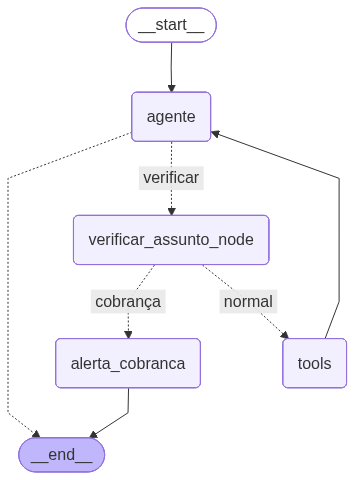

In [13]:
from IPython.display import Image
Image(grafo_condicional.get_graph().draw_mermaid_png())

In [14]:
# Célula 10 — Teste: e-mail normal (deve enviar)
print("=== E-mail NORMAL ===")
resposta = invocar_grafo(
    grafo_condicional,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Reunião amanhã' "
    "e corpo 'Confirmando nossa reunião para amanhã às 10h.'"
)
print(resposta)

=== E-mail NORMAL ===
Perfeito! O e-mail foi enviado com sucesso para aluno02@curso.ia com o assunto 'Reunião amanhã' e a mensagem confirmando a reunião para amanhã às 10h.


In [15]:
# Célula 11 — Teste: e-mail de cobrança (deve bloquear)
print("=== E-mail de COBRANÇA ===")
resposta = invocar_grafo(
    grafo_condicional,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Cobrança de mensalidade' "
    "e corpo 'Sua mensalidade está em aberto. Por favor regularize.'"
)
print(resposta)

=== E-mail de COBRANÇA ===
⚠️  ALERTA: e-mail com assunto de cobrança detectado: 'cobrança de mensalidade'.
    Envio bloqueado automaticamente pelo sistema.


---
## Parte D — Human-in-the-loop

Bloquear silenciosamente não é ideal — melhor **perguntar ao humano** antes de agir.  

LangGraph oferece `interrupt()`: quando chamado dentro de um nó, o grafo **pausa completamente**.  
O estado fica salvo num `checkpointer` (memória de sessão).  
O humano responde, e o grafo **retoma de onde parou**.

```
START → agente → verificar
                 ↙         ↘
           cobrança?      normal?
               ↓               ↓
         PAUSA ← interrupt()  tools → agente → END
               ↓
         humano responde
               ↓
         sim → tools → agente → END
         não → END
```

In [16]:
# Célula 12 — Grafo com human-in-the-loop
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

def no_confirmacao_cobranca(state: State) -> dict:
    """Pausa o grafo e pede confirmação humana antes de enviar e-mail de cobrança."""
    assunto = extrair_assunto(state)

    # interrupt() pausa o grafo aqui e devolve o valor para quem invocou
    confirmacao = interrupt(
        f"⚠️  E-mail de cobrança detectado!\n"
        f"   Assunto: '{assunto}'\n"
        f"   Deseja realmente enviar este e-mail? (sim/não)"
    )

    # Quando o grafo retoma, confirmacao tem a resposta do humano
    if confirmacao.strip().lower() in ("sim", "s", "yes", "y"):
        return {}  # segue para tools normalmente
    else:
        msg = AIMessage(content="Envio cancelado pelo usuário.")
        return {"messages": [msg]}


def confirmacao_para_onde(state: State) -> str:
    """Após a confirmação: envia ou encerra?"""
    ultima = state["messages"][-1]
    if isinstance(ultima, AIMessage) and "cancelado" in ultima.content:
        return END
    return "tools"


# Montar o grafo completo
builder3 = StateGraph(State)
builder3.add_node("agente", no_agente)
builder3.add_node("tools", no_tools)
builder3.add_node("verificar_assunto_node", verificar_assunto_node)
builder3.add_node("confirmacao_cobranca", no_confirmacao_cobranca)

builder3.add_edge(START, "agente")
builder3.add_conditional_edges(
    "agente",
    agente_para_onde,
    {"verificar": "verificar_assunto_node", END: END},
)
builder3.add_conditional_edges(
    "verificar_assunto_node",
    verificar_assunto,
    {"cobrança": "confirmacao_cobranca", "normal": "tools"},
)
builder3.add_conditional_edges(
    "confirmacao_cobranca",
    confirmacao_para_onde,
    {"tools": "tools", END: END},
)
builder3.add_edge("tools", "agente")

# MemorySaver: persiste o estado do grafo entre invocações
# Necessário para que o interrupt() funcione
checkpointer = MemorySaver()
grafo_hitl = builder3.compile(checkpointer=checkpointer)

print("Grafo com human-in-the-loop compilado.")

Grafo com human-in-the-loop compilado.


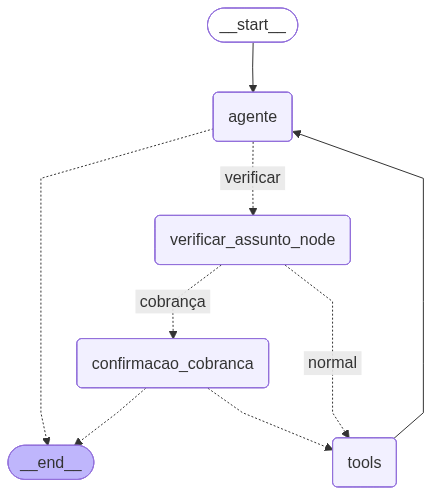

In [17]:
from IPython.display import Image
Image(grafo_hitl.get_graph().draw_mermaid_png())

In [18]:
# Célula 13 — Invocar com human-in-the-loop
#
# Cada conversa precisa de um thread_id único — é ele que identifica
# qual estado retomar quando o humano responder.

import uuid

def invocar_hitl(grafo, prompt):
    """Invoca o grafo com suporte a human-in-the-loop.
    
    Se o grafo pausar (interrupt), pede input do usuário e retoma.
    """
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    # Primeira invocação
    resultado = grafo.invoke(
        {"messages": [HumanMessage(content=prompt)]},
        config=config,
    )

    # Verificar se o grafo pausou (interrupt)
    interrupts = resultado.get("__interrupt__", [])
    if interrupts:
        # Mostrar a pergunta do grafo
        pergunta = interrupts[0].value
        print(pergunta)

        # Coletar resposta do humano
        resposta_humano = input("\nSua resposta: ").strip()

        # Retomar o grafo com a resposta
        resultado = grafo.invoke(
            Command(resume=resposta_humano),
            config=config,
        )

    return resultado["messages"][-1].content

print("Função invocar_hitl() pronta.")

Função invocar_hitl() pronta.


In [ ]:
# Célula 14 — Teste A: e-mail normal (sem interrupção)
print("=== E-mail NORMAL — sem interrupção ===")
resposta = invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Boas notícias' "
    "e corpo 'Tudo certo por aqui!'"
)
print(resposta)

=== E-mail NORMAL — sem interrupção ===
Parece que você está expressando frustração sobre algo! 😄

Porém, não tenho informações sobre o que você está se referindo especificamente. Para ajudá-lo melhor, poderia me esclarecer:

1. **Você precisa enviar um e-mail** relacionado a uma cobrança ou reclamação?
2. **Você está comentando sobre uma situação** e quer que eu o ajude a redigir uma mensagem?
3. **Há algo específico** que você gostaria que eu fizesse?

Se você precisar enviar um e-mail para alguém (professor, administrador, etc.), posso ajudá-lo! Nesse caso, me informe:
- **Para quem** (e-mail do destinatário)
- **Qual o assunto**
- **O que você quer dizer** na mensagem

Estou pronto para ajudar! 📧


In [20]:
# Célula 15 — Teste B: e-mail de cobrança — responder SIM
# O grafo vai pausar e pedir confirmação.
# Digite 'sim' quando aparecer o prompt.
print("=== E-mail de COBRANÇA — confirmar envio ===")
resposta = invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno03@curso.ia com assunto 'Cobrança de mensalidade' "
    "e corpo 'Sua mensalidade está em aberto.'"
)
print(resposta)

=== E-mail de COBRANÇA — confirmar envio ===
⚠️  E-mail de cobrança detectado!
   Assunto: 'cobrança de mensalidade'
   Deseja realmente enviar este e-mail? (sim/não)
Envio cancelado pelo usuário.


In [21]:
# Célula 16 — Teste C: e-mail de cobrança — responder NÃO
# Digite 'não' quando aparecer o prompt.
print("=== E-mail de COBRANÇA — cancelar envio ===")
resposta = invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno04@curso.ia com assunto 'Cobrança atrasada' "
    "e corpo 'Você tem débitos pendentes.'"
)
print(resposta)

=== E-mail de COBRANÇA — cancelar envio ===
⚠️  E-mail de cobrança detectado!
   Assunto: 'cobrança atrasada'
   Deseja realmente enviar este e-mail? (sim/não)
O e-mail foi enviado com sucesso para aluno04@curso.ia com o assunto "Cobrança atrasada" e a mensagem "Você tem débitos pendentes."


---
## Resumo do Dia 4

| Conceito | O que aprendemos |
|---|---|
| `StateGraph` | Grafo onde cada nó lê e atualiza um estado compartilhado |
| `add_conditional_edges` | Bifurca o fluxo dependendo do conteúdo do estado |
| `ToolNode` | Nó pronto do LangGraph que executa as tools chamadas pelo LLM |
| `interrupt()` | Pausa o grafo e devolve o controle ao humano |
| `MemorySaver` | Persiste o estado do grafo para permitir retomada após interrupt |
| `Command(resume=...)` | Retoma o grafo pausado com a resposta do humano |

### O que vem no Dia 5

- **Arquitetura de dois níveis**: orquestrador + sub-agente, cada um como `StateGraph` separado
- **Sub-agente de alertas**: recebe tipo e detalhes, escolhe a skill correta, busca os destinatários e envia os e-mails — tudo sozinho
- **Orquestrador**: decide entre delegar alertas complexos (`enviar_alerta`) ou agir diretamente (`send_email`)
- **Skills** (`.md`): arquivos de conhecimento externo que o sub-agente lê para saber como formatar cada tipo de alerta
